In [9]:
from tqdm import tqdm
import json
import modelseedpy
import cobrakbase

In [10]:
kbase = cobrakbase.KBaseCache(token='555LI5PO2NYLO6VM3CSVYI7GLBC4P7QM', path='/storage/fliu/data/kbase/cache')
ws_ids = [155805, 163264]
d_genomes = {}
d_infos = {}
for ws_id in ws_ids:
    infos = kbase.list_workspace(ws_id)
    for info in tqdm(infos):
        if info.type == 'KBaseGenomes.Genome':
            genome = kbase.get_from_ws(str(info))
            d_genomes[str(info)] = genome
            d_infos[str(info)] = info

100%|██████████| 283/283 [00:32<00:00,  8.63it/s] 


In [13]:
import os
rast_annotation = {}
for filename in tqdm(os.listdir('../vault/')):
    if filename.startswith('rast_'):
        with open('../vault/' + filename, 'r') as fh:
            rast_data = json.load(fh)
            _d = {}
            for o in rast_data[0]['features']:
                _d[o['id']] = o.get('function', 'hypothetical protein')
            rast_annotation.update(_d)
len(rast_annotation)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:19<00:00,  3.87it/s]


1358000

In [18]:
from modelseedpy_ext.re.hash_seq import HashSeq
genome_h_proteins = {}
for ref, g in tqdm(d_genomes.items()):
    genome_h_proteins[ref] = {}
    for f in g.features:
        h = HashSeq(f.seq).hash_value
        genome_h_proteins[ref][f.id] = rast_annotation[h]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 450/450 [00:03<00:00, 138.71it/s]


In [30]:
import re
for ref, g in tqdm(d_genomes.items()):
    saved_annotations = genome_h_proteins[ref]
    for f in g.features:
        f.ontology_terms.clear()
        rast_annotation = saved_annotations[f.id]
        rast_functions = re.split("; | / | @", rast_annotation)
        for rast_functions in rast_functions:
            f.add_ontology_term('RAST', rast_functions)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 450/450 [00:06<00:00, 65.57it/s]


In [32]:
from modelseedpy.helpers import get_template, get_classifier
genome_classifier = get_classifier("knn_ACNP_RAST_filter_01_17_2023")

In [35]:
genome_class = {}
for ref, g in tqdm(d_genomes.items()):
    genome_class[ref] = genome_classifier.classify(g)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 450/450 [00:20<00:00, 21.64it/s]


In [38]:
templates = {}
templates['P'] = kbase.get_from_ws('GramPosModelTemplateV6_test', 12218)
templates['N'] = kbase.get_from_ws('GramNegModelTemplateV6_test', 12218)
templates['A'] = kbase.get_from_ws('ArchaeaModelTemplateV5_test', 12218)

In [39]:
templates

{'P': <cobrakbase.core.kbasefba.newmodeltemplate.NewModelTemplate at 0x2005803c410>,
 'N': <cobrakbase.core.kbasefba.newmodeltemplate.NewModelTemplate at 0x20021e52810>,
 'A': <cobrakbase.core.kbasefba.newmodeltemplate.NewModelTemplate at 0x1ff5cd57e50>}

In [51]:
import cobra
from modelseedpy import MSBuilder
for ref, g in tqdm(d_genomes.items()):
    template = templates[genome_class[ref]]
    builder = MSBuilder(g, template, d_infos[ref].id)
    model = builder.build(d_infos[ref].id, annotate_with_rast=False)
    cobra.io.save_json_model(model, f'M:/salterns/models/base/{d_infos[ref].id}.json')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 450/450 [6:10:46<00:00, 49.44s/it]


In [47]:
model

Name,Salt_Pond_MetaGSF2_B_H2O_MG_DASTool_bins_metabat.8.contigs__.RAST
Memory address,200641cea10
Number of metabolites,1138
Number of reactions,1130
Number of genes,956
Number of groups,624
Objective expression,1.0*bio1 - 1.0*bio1_reverse_b18f7
Compartments,"Cytosol, Extracellular"


In [52]:
mepe = {'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}

In [54]:
import pandas as pd
df_salt = pd.read_csv('../vault/salt.tsv', sep='\t', index_col=0)
d_taxa_data = df_salt.transpose().to_dict()

In [65]:
samples = {
    'unrestored': {
        'H2O': ['bin_all_R1_A_H2O_MG_per', 'bin_all_R1_B_H2O_MG_per',                                                    'bin_all_R2_B_H2O_MG_per', 'bin_all_R2_C_H2O_MG_per'],
        'D1':  ['bin_all_R1_A_D1_MG_per',  'bin_all_R1_B_D1_MG_per',                           'bin_all_R2_A_D1_MG_per', 'bin_all_R2_B_D1_MG_per',  'bin_all_R2_C_D1_MG_per'],
        'D2':  ['bin_all_R1_A_D2_MG_per',  'bin_all_R1_B_D2_MG_per',  'bin_all_R1_C_D2_MG_per',                          'bin_all_R2_B_D2_MG_per'],
    },
    'restored': {
        'H2O': ['bin_all_SF2_A_H2O_MG_per', 'bin_all_SF2_B_H2O_MG_per', 'bin_all_SF2_C_H2O_MG_per'],
        'D1':  ['bin_all_SF2_B_D1_MG_per',                              'bin_all_SF2_C_D1_MG_per'],
        'D2':  ['bin_all_SF2_A_D2_MG_per',  'bin_all_SF2_B_D2_MG_per',  'bin_all_SF2_C_D2_MG_per'],
    },
    'reference': {
        'H2O': ['bin_all_R2A_A_H2O_MG_per', 'bin_all_R2A_B_H2O_MG_per', 'bin_all_R2A_C_H2O_MG_per'],
        'D1':  ['bin_all_R2A_A_D1_MG_per',  'bin_all_R2A_B_D1_MG_per',  'bin_all_R2A_C_D1_MG_per'],
        'D2':  ['bin_all_R2A_A_D2_MG_per',  'bin_all_R2A_B_D2_MG_per',  'bin_all_R2A_C_D2_MG_per'],
    },
}

In [71]:
for zone in samples['unrestored']:
    for sample_id in samples['unrestored'][zone]:
        print(sample_id, d_taxa_data[g_id][sample_id])

bin_all_R1_A_H2O_MG_per 0.00%
bin_all_R1_B_H2O_MG_per 0.00%
bin_all_R2_B_H2O_MG_per 0.00%
bin_all_R2_C_H2O_MG_per 0.00%
bin_all_R1_A_D1_MG_per 0.04%
bin_all_R1_B_D1_MG_per 0.93%
bin_all_R2_A_D1_MG_per 3.67%
bin_all_R2_B_D1_MG_per 0.68%
bin_all_R2_C_D1_MG_per 0.64%
bin_all_R1_A_D2_MG_per 0.03%
bin_all_R1_B_D2_MG_per 0.56%
bin_all_R1_C_D2_MG_per 0.44%
bin_all_R2_B_D2_MG_per 4.53%


In [74]:
def _get_sum_perc(genomes, sample_ids):
    sum_perc = {}
    for g_id in genomes:
        _d_data = d_taxa_data[g_id]
        for sid in sample_ids:
            if sid not in sum_perc:
                sum_perc[sid] = 0
            sum_perc[sid] += float(_d_data[sid][:-1])
    return sum_perc
select_g_ids = set()
for g_id in mepe:
    if d_taxa_data[g_id]['gtdb_f'] == 'f__Rhodobacteraceae':
        print(d_taxa_data[g_id]['gtdb_d'], d_taxa_data[g_id]['gtdb_c'], d_taxa_data[g_id]['gtdb_f'], )
        select_g_ids.add(g_id)
for zone in samples['unrestored']:
    for sample_id in samples['unrestored'][zone]:
        print(zone, sample_id, _get_sum_perc(select_g_ids, [sample_id]))

d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
d__Bacteria c__Alphaproteobacteria f__Rhodobacteraceae
H2O bin_al

In [64]:
d_taxa_data[g_id]

{'gtdb_d': 'd__Bacteria',
 'gtdb_p': 'p__Proteobacteria',
 'gtdb_c': 'c__Alphaproteobacteria',
 'gtdb_o': 'o__Rhodobacterales',
 'gtdb_f': 'f__Rhodobacteraceae',
 'unrestored': '4.53%',
 'restored': '0.00%',
 'natural': '0.02%',
 'bin_all_R1_A_D1_MG_per': '0.04%',
 'bin_all_R1_B_D1_MG_per': '0.93%',
 'bin_all_R2_A_D1_MG_per': '3.67%',
 'bin_all_R2_B_D1_MG_per': '0.68%',
 'bin_all_R2_C_D1_MG_per': '0.64%',
 'bin_all_R1_A_D2_MG_per': '0.03%',
 'bin_all_R1_B_D2_MG_per': '0.56%',
 'bin_all_R1_C_D2_MG_per': '0.44%',
 'bin_all_R2_B_D2_MG_per': '4.53%',
 'bin_all_R1_A_H2O_MG_per': '0.00%',
 'bin_all_R1_B_H2O_MG_per': '0.00%',
 'bin_all_R2_B_H2O_MG_per': '0.00%',
 'bin_all_R2_C_H2O_MG_per': '0.00%',
 'bin_all_R2_restored_C_black_MG_per': '0.11%',
 'bin_all_R2_restored_D_shore_MG_per': '0.00%',
 'bin_all_R2_restored_H2O_MG_per': '0.00%',
 'bin_all_R2A_A_D1_MG_per': '0.01%',
 'bin_all_R2A_B_D1_MG_per': '0.02%',
 'bin_all_R2A_C_D1_MG_per': '0.00%',
 'bin_all_R2A_A_D2_MG_per': '0.01%',
 'bin_all_R

find a growth range to match methane

Growth rate of entire community/cm3 * [[Glycine betaine in cell]](2M) * volume of cell per gram of cell
mol gylcine betaine

In [3]:
import tarfile
from tqdm import tqdm
rast_annotation = {}
with tarfile.open('/storage/fliu/data/cliff/genomes/salterns.rast.tar.gz', "r:gz") as fh_tar:
    for member in tqdm(fh_tar.getmembers()):
        if member.isfile():
            file = fh_tar.extractfile(member)
            if file:
                content = file.read()
                rast_data = json.loads(bytearray(content))
                _d = {}
                for o in rast_data[0]['features']:
                    _d[o['id']] = o.get('function', 'hypothetical protein')
                rast_annotation.update(_d)
len(rast_annotation)

100%|██████████| 68/68 [00:06<00:00,  9.76it/s]


1358000

In [4]:
unique_annotation = set()
for h in rast_annotation:
    unique_annotation.add(rast_annotation[h])

In [5]:
len(unique_annotation)

14708

In [ ]:
for v in unique_annotation:
    if '' in v.lower()

In [14]:
mepe = {
    'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.20.contigs',
 'Salt_Pond_MetaG_R1_B_D1_MG_DASTool_bins_metabat.32.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_concoct_out.51.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.27.contigs',
 'Salt_Pond_MetaG_R1_B_D2_MG_DASTool_bins_metabat.28.contigs',
 'Salt_Pond_MetaG_R1_B_H2O_MG_DASTool_bins_metabat.7.contigs',
 'Salt_Pond_MetaG_R1_C_D1_MG_DASTool_bins_metabat.31.contigs',
 'Salt_Pond_MetaG_R1_C_H2O_MG_DASTool_bins_concoct_out.79.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.35.contigs',
 'Salt_Pond_MetaG_R2_A_D1_MG_DASTool_bins_concoct_out.49.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.14.contigs',
 'Salt_Pond_MetaG_R2_A_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.143.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_concoct_out.32.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.10.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.16.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.19.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.38.contigs',
 'Salt_Pond_MetaG_R2_B_D2_MG_DASTool_bins_metabat.55.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.88.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs',
 'Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_metabat.17.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.18.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.45.contigs',
 'Salt_Pond_MetaG_R2_C_D2_MG_DASTool_bins_concoct_out.47.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_concoct_out.17.contigs',
 'Salt_Pond_MetaG_R2_restored_C_black_MG_DASTool_bins_metabat.8.contigs'}

In [30]:
mepe_genomes = {}
_info_id_to_genome = {}
for ref in d_genomes:
    info = d_infos[ref]
    _info_id_to_genome[info.id] = d_genomes[ref]
for mepe_id in mepe:
    if mepe_id + '__.RAST' in _info_id_to_genome:
        mepe_genomes[mepe_id] = _info_id_to_genome[mepe_id + '__.RAST']
    else:
        print(mepe_id)

In [46]:
from modelseedpy_ext.re.hash_seq import HashSeq
import re
for i in mepe_genomes:
    genome = mepe_genomes[i]
    for feature in genome.features:
        feature.ontology_terms = {}
        h = HashSeq(feature.seq).hash_value
        _rast_annotation = rast_annotation[h]
        rast_functions = re.split("; | / | @", _rast_annotation)
        for rast_function in rast_functions:
            feature.add_ontology_term('RAST', rast_function)

In [66]:
ftr_scan = [
    'Phosphonate ABC transporter substrate-binding protein PhnD (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter ATP-binding protein PhnC (TC 3.A.1.9.1)',
    'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)',
    'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)',
    'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)',
    'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
]

In [ ]:
rxn_scan = ['rxn26456_c0', 'rxn26457_c0', 'rxs43120_c0', 'rxn26447_c0', 'rxn04651_c0']
_plot_data = {}
for model_id in models_base:
    model_base = models_base[model_id]
    _plot_data[model_id] = {x: x in model_base.reactions for x in rxn_scan}

In [70]:
from modelseedpy.core.msgenome import normalize_role
_plot_data = {}
for model_id in mepe_genomes:
    genome = mepe_genomes[model_id]
    _plot_data[model_id] = {}
    genome_nmz_roles = set()
    for f in genome.features:
        for rast_function in f.ontology_terms.get('RAST', []):
            f_nmz = normalize_role(rast_function)
            if 'lactate' in f_nmz:
                print(model_id, rast_function)
            genome_nmz_roles.add(f_nmz)
    for ftr_id in ftr_scan:
        nmz = normalize_role(ftr_id)
        _plot_data[model_id][ftr_id] = nmz in genome_nmz_roles

Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Predicted L-lactate dehydrogenase, Fe-S oxidoreductase subunit YkgE
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Predicted L-lactate dehydrogenase, Iron-sulfur cluster-binding subunit YkgF
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Predicted L-lactate dehydrogenase, hypothetical protein subunit YkgG
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs (2R)-sulfolactate sulfo-lyase subunit beta (EC 4.4.1.24)
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Acetolactate synthase small subunit (EC 2.2.1.6)
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Acetolactate synthase large subunit (EC 2.2.1.6)
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Acetolactate synthase small subunit (EC 2.2.1.6)
Salt_Pond_MetaG_R2_C_D1_MG_DASTool_bins_concoct_out.95.contigs Fe-S protein, homolog of lactate dehydrogenase SO1521
Salt_Pond_MetaG_R2_C_D1_M

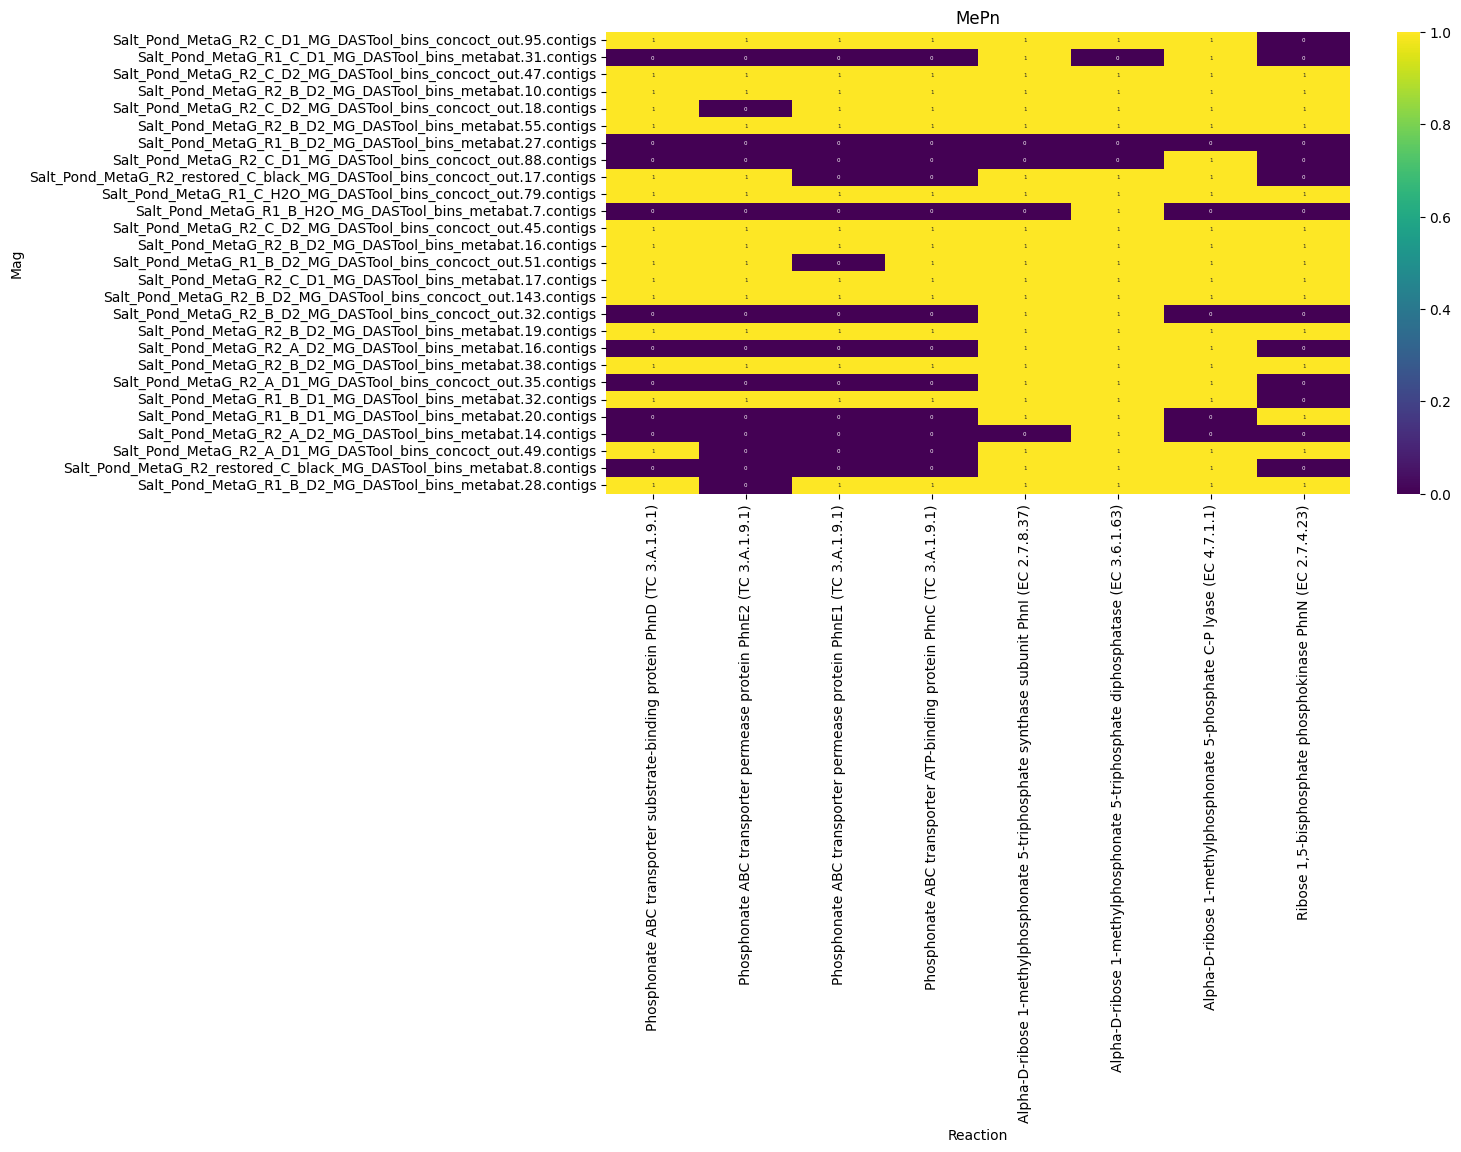

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = _plot_data

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("MePn")
plt.ylabel("Mag")
plt.xlabel("Reaction")
plt.show()

In [69]:
for k in unique_annotation:
    if 'lactate' in k.lower():
        print(k)

Predicted L-lactate dehydrogenase, Fe-S oxidoreductase subunit YkgE
Predicted L-lactate dehydrogenase, Iron-sulfur cluster-binding subunit YkgF
D-lactate dehydrogenase (EC 1.1.1.28)
Acetolactate synthase small subunit (EC 2.2.1.6)
Fe-S protein, homolog of lactate dehydrogenase SO1521
L-lactate dehydrogenase (EC 1.1.1.27)
(2R)-sulfolactate sulfo-lyase subunit alpha (EC 4.4.1.24)
Acetolactate synthase, catabolic (EC 2.2.1.6)
(R)-2-hydroxyacid dehydrogenase, similar to L-sulfolactate dehydrogenase (EC 1.1.1.272)
Probable 2-phosphosulfolactate phosphatase (EC 3.1.3.71)
IlvB (Bacterial acetolactate synthase) -like isoform 1
Predicted L-lactate dehydrogenase, hypothetical protein subunit YkgG
Phosphosulfolactate synthase (EC 4.4.1.19)
Acetolactate synthase
Alpha-acetolactate decarboxylase (EC 4.1.1.5)
Acetolactate synthase large subunit (EC 2.2.1.6)
hypothetical protein; possible 2-phosphosulpholactate phosphatase
D-lactate dehydrogenase
Predicted L-lactate dehydrogenase, Fe-S oxidoreductase

In [ ]:
ftr_scan = [
    'Phosphonate ABC transporter substrate-binding protein PhnD (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter permease protein PhnE2 (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter permease protein PhnE1 (TC 3.A.1.9.1)',
    'Phosphonate ABC transporter ATP-binding protein PhnC (TC 3.A.1.9.1)',
    'Alpha-D-ribose 1-methylphosphonate 5-triphosphate synthase subunit PhnI (EC 2.7.8.37)',
    'Alpha-D-ribose 1-methylphosphonate 5-triphosphate diphosphatase (EC 3.6.1.63)',
    'Alpha-D-ribose 1-methylphosphonate 5-phosphate C-P lyase (EC 4.7.1.1)',
    'Ribose 1,5-bisphosphate phosphokinase PhnN (EC 2.7.4.23)',
]

In [12]:
from modelseedpy_ext.re.hash_seq import HashSeq
import re
for ref, genome in d_genomes.items():
    for feature in genome.features:
        feature.ontology_terms = {}
        h = HashSeq(feature.seq).hash_value
        _rast_annotation = rast_annotation[h]
        rast_functions = re.split("; | / | @", _rast_annotation)
        for rast_function in rast_functions:
            feature.add_ontology_term('RAST', rast_function)

In [7]:
for i in unique_annotation:
    if 'betaine reductase' in i.lower():
        print(i)

Glycine/sarcosine/betaine reductase protein A @ selenocysteine-containing
Betaine reductase component B alpha subunit (EC 1.21.4.4)
Glycine/sarcosine/betaine reductase component C chain 1
Glycine/sarcosine/betaine reductase component C chain 2
Betaine reductase component B beta subunit (EC 1.21.4.4) @ selenocysteine-containing


In [35]:
df_meta = pd.read_csv('../salt.tsv', sep='\t', index_col=0)
d_metadata = df_meta.transpose().to_dict()

In [70]:
betaine_reductase = [
    'Glycine/sarcosine/betaine reductase protein A',
    'Betaine reductase component B alpha subunit (EC 1.21.4.4)',
    'Glycine/sarcosine/betaine reductase component C chain 1',
    'Glycine/sarcosine/betaine reductase component C chain 2',
    'Betaine reductase component B beta subunit (EC 1.21.4.4)',
]
ftr_scan = betaine_reductase
from modelseedpy.core.msgenome import normalize_role
_plot_data = {}
index = 0
model_ids = {}
for ref, genome in d_genomes.items():
    model_id = d_infos[ref].id
    if model_id[:-7] in d_metadata:
        #genome = mepe_genomes[model_id]
        genome_nmz_roles = set()
        _scan = {}
        for f in genome.features:
            for rast_function in f.ontology_terms.get('RAST', []):
                f_nmz = normalize_role(rast_function)
                genome_nmz_roles.add(f_nmz)
        for ftr_id in ftr_scan:
            nmz = normalize_role(ftr_id)
            _scan[ftr_id] = nmz in genome_nmz_roles

        _metadata = d_metadata[model_id[:-7]]
        gtdb_d = 'B' if _metadata['gtdb_d'] == 'd__Bacteria' else 'A'
        _label = f'{gtdb_d};{_metadata["gtdb_p"]};{_metadata["gtdb_c"]};{_metadata["gtdb_o"]};{_metadata["gtdb_f"]} [{index}] {_metadata["unrestored"]}, {_metadata["restored"]},{_metadata["natural"]}'
        if True in set(_scan.values()):
            model_ids[model_id] = (genome, _label)
            _plot_data[_label] = _scan
            index += 1

In [71]:
thx = [
    'Thioredoxin family protein',
    'Thioredoxin 2',
    'Thioredoxin reductase (EC 1.8.1.9)',
    'Soluble pyridine nucleotide transhydrogenase (EC 1.6.1.1)',
    'NAD(P) transhydrogenase N-domain of subunit alpha (EC 1.6.1.2)',
    'NAD(P) transhydrogenase C-domain of subunit alpha (EC 1.6.1.2)',
    'NAD(P) transhydrogenase subunit beta (EC 1.6.1.2)'
]
for model_id, (genome, _label) in model_ids.items():
    model_id = d_infos[ref].id
    #genome = mepe_genomes[model_id]
    genome_nmz_roles = set()
    for f in genome.features:
        for rast_function in f.ontology_terms.get('RAST', []):
            f_nmz = normalize_role(rast_function)
            genome_nmz_roles.add(f_nmz)
    for ftr_id in thx:
        nmz = normalize_role(ftr_id)
        _plot_data[_label][ftr_id] = nmz in genome_nmz_roles

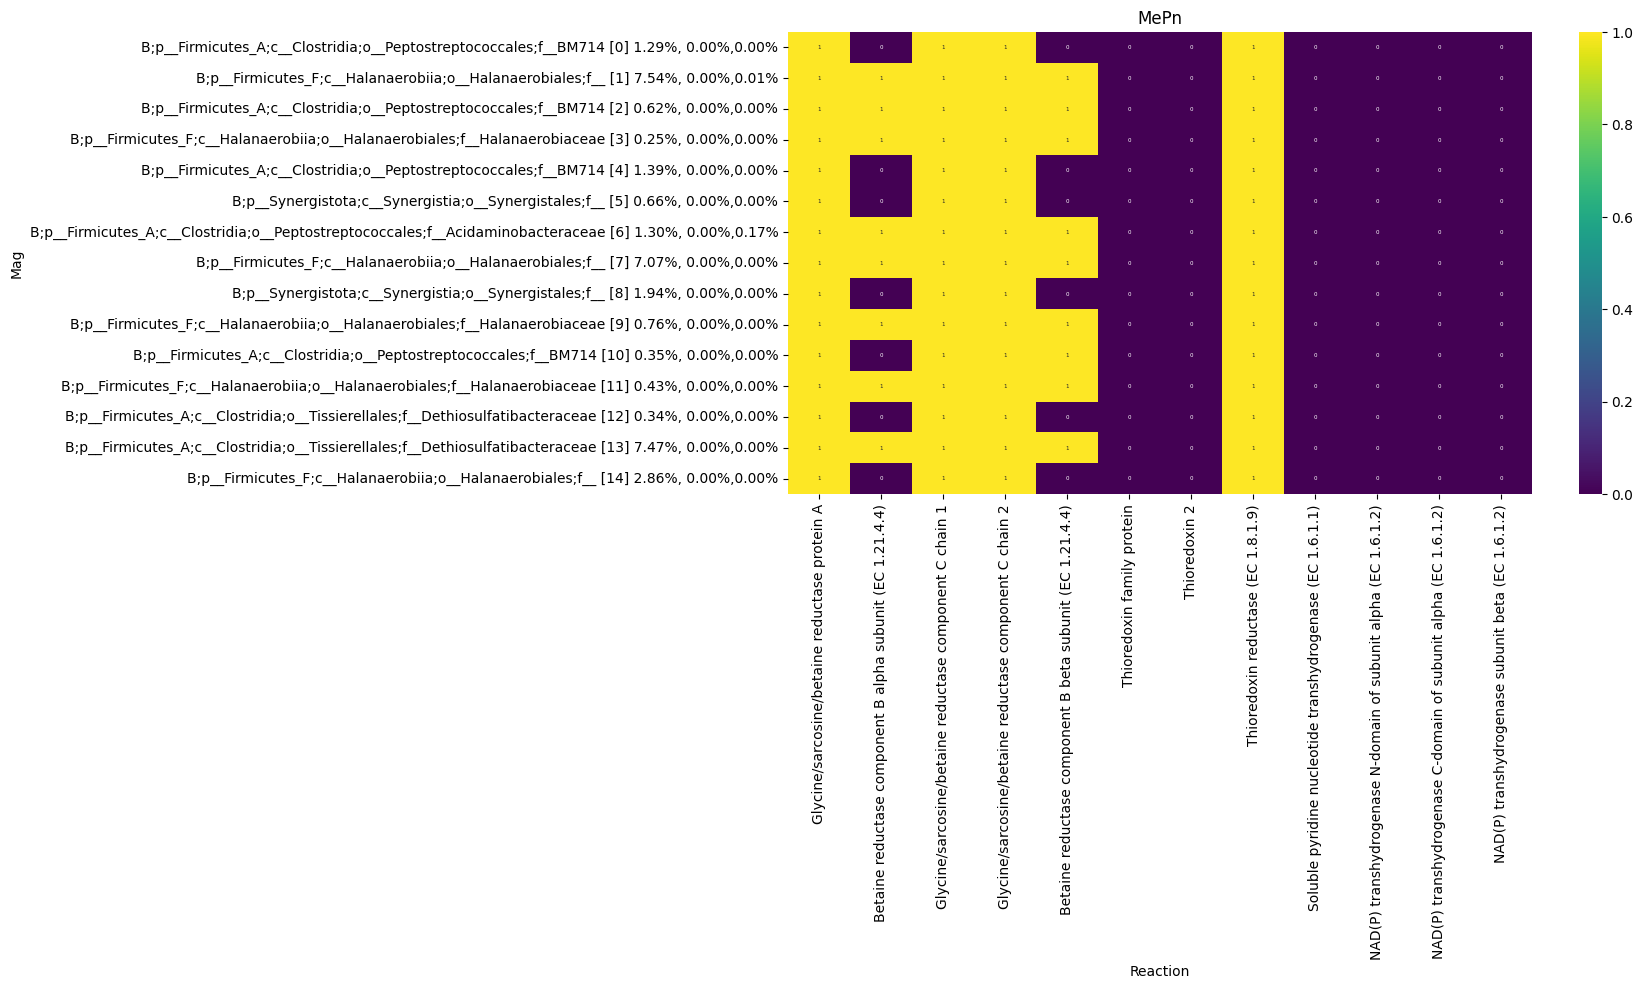

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Corrected dictionary
d = _plot_data

# Convert to DataFrame
df = pd.DataFrame.from_dict(d, orient='index')
plt.figure(figsize=(12, 6))
# Plot heatmap
sns.heatmap(df, annot=True, cmap='viridis', annot_kws={"size": 4})
plt.title("MePn")
plt.ylabel("Mag")
plt.xlabel("Reaction")
plt.show()

In [68]:
for i in unique_annotation:
    if 'transhydrogenase' in i.lower():
        print(i)

Soluble pyridine nucleotide transhydrogenase (EC 1.6.1.1)
NAD(P) transhydrogenase N-domain of subunit alpha (EC 1.6.1.2) / NAD(P) transhydrogenase C-domain of subunit alpha (EC 1.6.1.2)
NAD(P) transhydrogenase C-domain of subunit alpha (EC 1.6.1.2)
NAD(P) transhydrogenase subunit beta (EC 1.6.1.2)
NAD(P) transhydrogenase N-domain of subunit alpha (EC 1.6.1.2)


In [ ]:
Thioredoxin related protein PA2694
Thioredoxin domain-containing protein

In [ ]:
Adenylyl-sulfate reductase [thioredoxin] (EC 1.8.4.10) red -> ox
bet -> tma red -> ox